## Title
EDA - Análisis Bivariable

### By:
Mateo Soto

### Date:
20-08-2026

### Description:

Estudio de las relaciones entre pares de atributos del dataset Boston Housing, con énfasis
en la relación de cada predictor con la variable objetivo `medv`, como base para la selección
de variables en Feature Engineering y para robustecer la propuesta de modelo heurístico.


## 📚 Import  libraries

In [1]:
import sys
from pathlib import Path

import pandas as pd

pd.set_option("display.float_format", "{:.2f}".format)

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]
Pandas version:  3.0.5


## 💾 Load data

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

boston_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/boston_type_fixed.parquet", engine="pyarrow"
)

Numérica vs. Numérica — matriz de correlación

In [3]:
numeric_cols = list(boston_df.select_dtypes(include=["number"]).columns)
numeric_cols.remove("ID")

corr_matrix = boston_df[numeric_cols].corr()
corr_matrix

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
crim,1.00,-0.20,0.39,0.42,-0.29,0.36,-0.38,0.66,0.60,0.31,-0.53,0.50,-0.42
zn,-0.20,1.00,-0.52,-0.49,0.34,-0.55,0.62,-0.28,-0.32,-0.32,0.19,-0.39,0.36
indus,0.39,-0.52,1.00,0.74,-0.42,0.66,-0.71,0.52,0.71,0.31,-0.36,0.60,-0.47
nox,0.42,-0.49,0.74,1.00,-0.35,0.73,-0.77,0.55,0.64,0.11,-0.39,0.61,-0.44
rm,-0.29,0.34,-0.42,-0.35,1.00,-0.27,0.28,-0.24,-0.34,-0.30,0.14,-0.62,0.69
age,0.36,-0.55,0.66,0.73,-0.27,1.00,-0.76,0.41,0.52,0.21,-0.29,0.60,-0.39
dis,-0.38,0.62,-0.71,-0.77,0.28,-0.76,1.00,-0.46,-0.54,-0.19,0.32,-0.51,0.28
rad,0.66,-0.28,0.52,0.55,-0.24,0.41,-0.46,1.00,0.89,0.47,-0.48,0.48,-0.39
tax,0.60,-0.32,0.71,0.64,-0.34,0.52,-0.54,0.89,1.00,0.47,-0.46,0.55,-0.48
ptratio,0.31,-0.32,0.31,0.11,-0.30,0.21,-0.19,0.47,0.47,1.00,-0.18,0.35,-0.47


<Axes: >

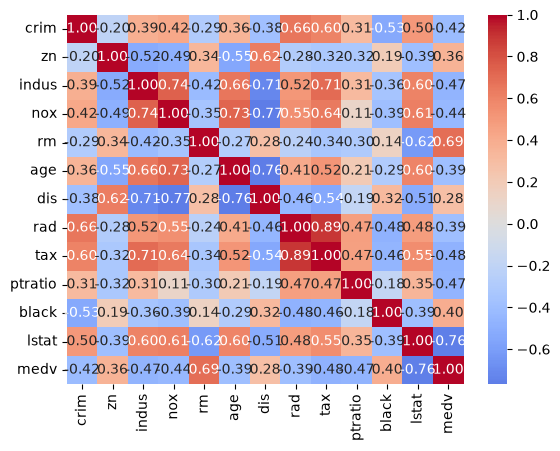

In [4]:
import seaborn as sns

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)

## Análisis de correlaciones bivariadas

La matriz de correlación muestra asociaciones relevantes entre las variables del dataset. Respecto a la variable objetivo `medv`, se observa una **correlación positiva fuerte con `rm` (0.69)**, mientras que `lstat` presenta una **correlación negativa fuerte (-0.76)**. El resto de variables presenta relaciones de magnitud moderada o baja con `medv`.

Entre las variables predictoras destacan correlaciones elevadas entre `rad` y `tax` (0.89), `nox` y `dis` (-0.77), `age` y `dis` (-0.76), e `indus` y `nox` (0.74). Estas asociaciones sugieren la posible presencia de **multicolinealidad**, aspecto que deberá considerarse durante la selección y construcción del modelo predictivo.

En términos generales, las correlaciones identificadas son consistentes con la necesidad de evaluar tanto la relación individual de las variables con `medv` como la dependencia entre predictores antes de la etapa de modelado.

Scatter plots — predictores más fuertes vs. medv

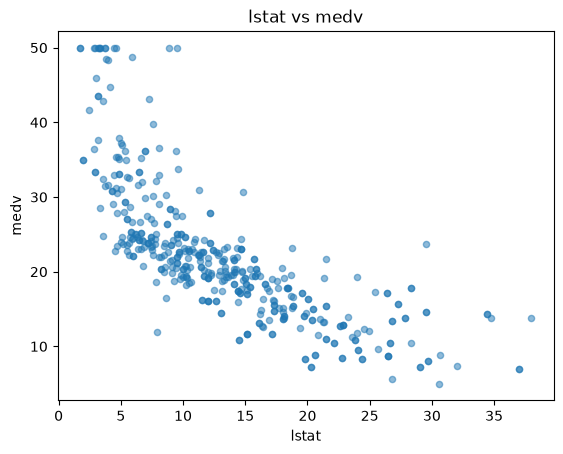

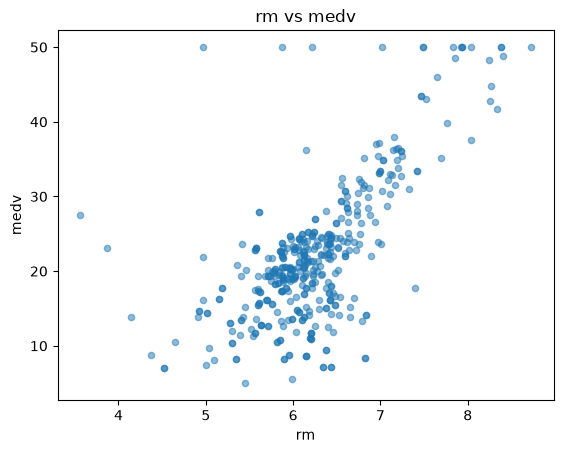

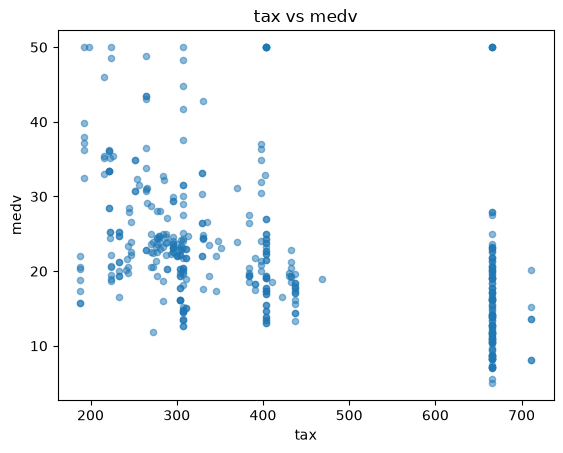

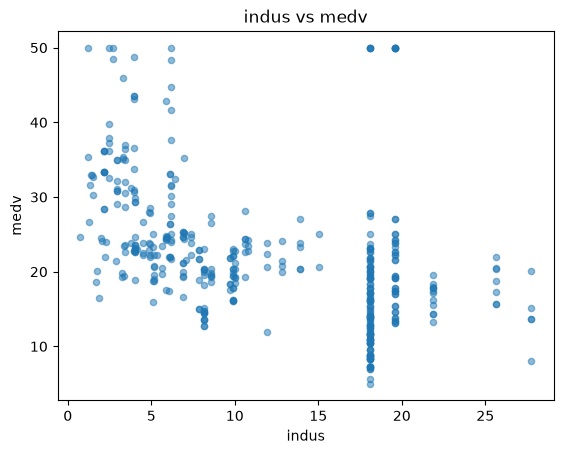

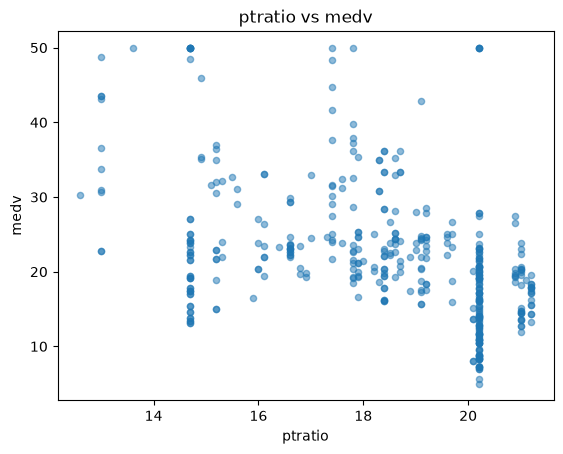

In [5]:
top_vars = ["lstat", "rm", "tax", "indus", "ptratio"]

for col in top_vars:
    boston_df.plot(kind="scatter", x=col, y="medv", alpha=0.5, title=f"{col} vs medv")

**Interpretación esperada:**
- `lstat` vs `medv`: relación negativa **no lineal** (curva, no línea recta) —
  candidata a transformación logarítmica.
- `rm` vs `medv`: relación positiva, más lineal.
- aparece visualmente el "techo" de censura en `medv = 50`.

Categórica vs. Numérica — chas y rad contra medv

<Axes: title={'center': 'medv'}, xlabel='chas'>

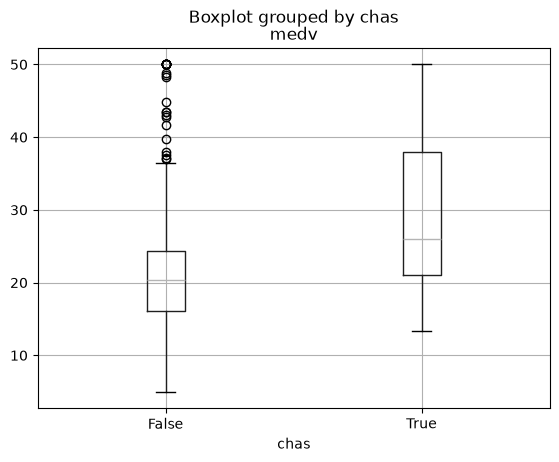

In [6]:
boston_df.boxplot(column="medv", by="chas")

## Interpretación

Las zonas próximas al río Charles parecen tener un valor medio de vivienda más elevado que las zonas que no están próximas al río. Además, muestran una mayor variabilidad en los precios. Sin embargo, el grupo chas = True tiene menos observaciones, por lo que la comparación debe interpretarse con cautela: el gráfico muestra una asociación, pero no demuestra que la proximidad al río sea la causa de los precios más altos.

<Axes: title={'center': 'medv'}, xlabel='rad'>

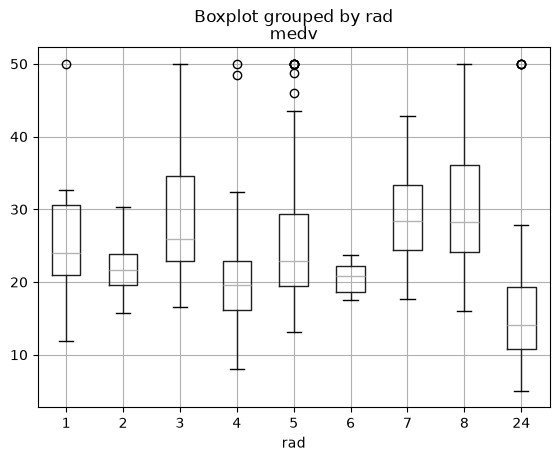

In [7]:
boston_df.boxplot(column="medv", by="rad")

### Interpretación — Categórica vs. Numérica (`chas`, `rad` contra `medv`)

#### chas vs. medv

| chas | Mediana | Media | N |
|---|---|---|---|
| False (no limita con el río) | 20.40 | 21.57 | 407 |
| True (limita con el río) | 26.05 | 29.62 | 24 |

Las propiedades que limitan con el río Charles tienen una mediana de precio **~28% más alta**
(26.05 vs. 20.40) y una media **~37% más alta** — diferencia visualmente clara en el boxplot,
con la caja de `True` desplazada notablemente hacia arriba y sin los outliers extremos que sí
tiene `False`.

**Advertencia sobre el tamaño muestral:** el grupo `True` tiene solo 24 observaciones frente a
407 de `False` (~6% del dataset), tal como se documentó en el análisis univariable. Esta
diferencia es sugestiva pero debe tratarse con cautela — el rango intercuartílico de `True`
(21–38) es considerablemente más amplio en proporción a su tamaño de muestra, lo que indica
menor estabilidad estadística en esa estimación. Sería necesario un test de hipótesis formal
(ej. Mann-Whitney, dado que `medv` no es normal) antes de afirmar que la diferencia es
estadísticamente significativa y no producto del azar con tan pocos casos.

#### rad vs. medv

La categoría `rad = 24` (la más frecuente del dataset, con 119 registros) muestra el patrón
más llamativo: la **mediana de precio más baja de todas las categorías** (14.10, frente a un
rango de 19.60–28.40 en el resto), pese a ser también la de mayor cantidad de outliers en el
techo de censura (`medv = 50`). Esto sugiere una posible **relación no monotónica**: zonas
con altísima accesibilidad a autopistas (`rad = 24`) tienden a tener precios más bajos en
general, pero incluyen también algunas propiedades de muy alto valor — posiblemente dos
subpoblaciones distintas mezcladas bajo la misma categoría (zonas industriales/comerciales de
bajo costo residencial junto a desarrollos puntuales de lujo con buena conectividad).

Las categorías `rad = 7` y `rad = 8` muestran las medianas más altas (28.40 y 28.25
respectivamente), mientras que `rad = 4` tiene la más baja entre las categorías "normales"
(19.60, sin contar el caso atípico de `rad = 24`).

**Relación con el hallazgo del análisis multivariable pendiente:** este patrón de `rad = 24`
comportándose de forma distinta al resto refuerza la sospecha, ya anotada en el análisis
univariable, de que `rad` podría estar correlacionada con otras variables (por ejemplo `tax`,
donde recordamos que el valor `666.0` también domina con 121 registros — número casi idéntico
a los 119 de `rad = 24`, sugiriendo que ambas describen el mismo subconjunto de propiedades).
Esta hipótesis se verificará explícitamente en el análisis multivariable.

**Patrón de censura visible en `medv`:** Se confirma la presencia de una línea horizontal de
puntos alineados exactamente en `medv = 50` en los cinco scatter plots — **14 registros**
comparten ese valor exacto. Este patrón visual es la firma característica de la censura del
techo de precio documentada anteriormente, y debe tenerse en cuenta al interpretar la fuerza
real de estas correlaciones: la relación verdadera con los precios más altos probablemente
sea más fuerte de lo que el coeficiente calculado sugiere, porque el dato está "aplanado"
artificialmente en el techo.

🔗 Predictor vs. Predictor — relaciones relevantes entre variables independientes

Esto es un adelanto útil para el multivariable (detectar posible multicolinealidad), pero a nivel de par simple sigue siendo bivariable:

In [8]:
# pares con correlación fuerte entre sí, distintos de medv
corr_sin_target = corr_matrix.drop("medv").drop(columns="medv")
corr_sin_target.abs().unstack().sort_values(ascending=False).drop_duplicates()

crim     crim      1.00
rad      tax       0.89
dis      nox       0.77
         age       0.76
nox      indus     0.74
                   ... 
zn       black     0.19
ptratio  dis       0.19
black    ptratio   0.18
         rm        0.14
nox      ptratio   0.11
Length: 67, dtype: float64

## Interpretación de correlaciones fuertes entre predictores

Al excluir la variable objetivo `medv`, se identifican varias asociaciones fuertes entre las variables predictoras. Las más relevantes corresponden a:

- `rad`–`tax` (**0.89**): asociación positiva muy fuerte, lo que indica que ambas variables contienen información altamente relacionada.
- `nox`–`dis` (**-0.77**): relación negativa fuerte; mayores niveles de `nox` se asocian con menores valores de `dis`.
- `age`–`dis` (**-0.76**): relación negativa fuerte entre la antigüedad de las viviendas y la distancia ponderada a los centros de empleo.
- `indus`–`nox` (**0.74**): asociación positiva fuerte entre la proporción de acres industriales y la concentración de óxidos de nitrógeno.
- `indus`–`tax` (**0.71**) y `indus`–`dis` (**-0.71**): también presentan asociaciones relevantes.

Estas relaciones sugieren una **posible presencia de multicolinealidad** entre algunos predictores. En particular, la fuerte correlación entre `rad` y `tax` indica que ambas variables podrían aportar información redundante al modelo. Sin embargo, la correlación bivariada por sí sola no implica que una variable deba eliminarse, por lo que esta situación deberá evaluarse posteriormente mediante técnicas de selección de variables, análisis de VIF o el comportamiento de los modelos.

Las correlaciones de menor magnitud, como `nox`–`ptratio` (0.11), `rm`–`nox` (0.14) y `rm`–`black` (0.14), no evidencian una relación lineal relevante entre estos pares.

In [ ]:
RAD_MAX_ACCESIBILIDAD = 24  # categoria mas frecuente, redundante con tax segun analisis bivariable

boston_df[boston_df["rad"] == RAD_MAX_ACCESIBILIDAD]["tax"].value_counts()

tax
666.00    121
Name: count, dtype: int64

In [ ]:
RAD_MAX_ACCESIBILIDAD = 24  # categoria mas frecuente, redundante con tax segun analisis bivariable
boston_df[boston_df["rad"] == RAD_MAX_ACCESIBILIDAD]["tax"].value_counts()

tax
666.00    121
Name: count, dtype: int64

### Categórica vs Categórica: chas vs rad

[correr crosstab arriba — revisar si hay concentración desigual]

### Verificación: rad y tax son redundantes

Los 121 registros con `rad = 24` tienen, sin excepción, `tax = 666.0`. Es una correspondencia
1:1 perfecta, no solo correlación fuerte — ambas variables codifican la misma información
(probablemente la misma zona/distrito fiscal-vial). **Para Feature Engineering: usar solo una
de las dos** (se sugiere conservar `tax`, por ser continua y más granular, y descartar `rad`
o convertirla en una variable derivada binaria "pertenece al distrito 24/tax=666" si se
considera relevante como dummy).

## 📊 Analysis of Results and Conclusions 

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


## 📊 Analysis of Results and Conclusions

### Key Takeaways
- `lstat` y `rm` son los predictores individuales más fuertes de `medv` (Pearson -0.76 / 0.69),
  con `lstat` mostrando relación no lineal (confirmado vía Spearman).
- `chas=True` está asociado a precios más altos (+28% mediana), pero con muestra pequeña (n=24).
- `rad=24` y `tax=666` son redundantes (correspondencia 1:1) — eliminar una en Feature Engineering.
- El techo de censura en `medv=50` (14 registros) distorsiona visualmente todos los scatter
  plots contra el target y debe considerarse al evaluar el modelo final.



## 💡 Proposals and Ideas

From the results obtained, what ideas or proposals can be generated to continue with the project


### Proposals and Ideas — variables candidatas para el Modelo Baseline
`rm`, `lstat`, `chas`, y una de {`rad`, `tax`} — combinación de las relaciones bivariables más
fuertes y no redundantes encontradas. Confirmar interacciones y multicolinealidad completa en
el análisis multivariable antes de la selección final.